<div align="center">

# <font color="#FF5733">🌍 AI-Powered Climate Resilience and Crop Yield Prediction for African Agriculture</font>

<br>

| | |
|:---:|:---:|
| <font size="5">**👨‍💻 Author**</font> | <font size="5">**Patrick John**</font> |


<br>

---

### 🔗 **Links**

| | |
|:---:|:---:|
| <font size="4"> **GitHub**</font> | <font size="4">[github.com/patrickjohnulad-bot/Maize-yield-predictor](https://github.com/patrickjohnulad-bot/Maize-yield-predictor)</font> |
| <font size="4">🚀 **Live Demo**</font> | <font size="4">[Maize Yield Predictor Streamlit App](https://maize-yield-predictor-k7tkuagktixqd4hnssebiv.streamlit.app/)</font> |

</div>

In [28]:
# IMPORTS AND DATA LOADING
import pandas as pd
import numpy as np
import seaborn as sns
import random
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.svm import SVR
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.utils import resample
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
random.seed(42)

In [3]:
data = pd.read_csv("rwanda_climate_maize_dataset.csv")

cols = ["temperature_C", "rainfall", "maize_yield"]
data[cols] = data[cols].apply(pd.to_numeric, errors="coerce")
data = data.dropna()

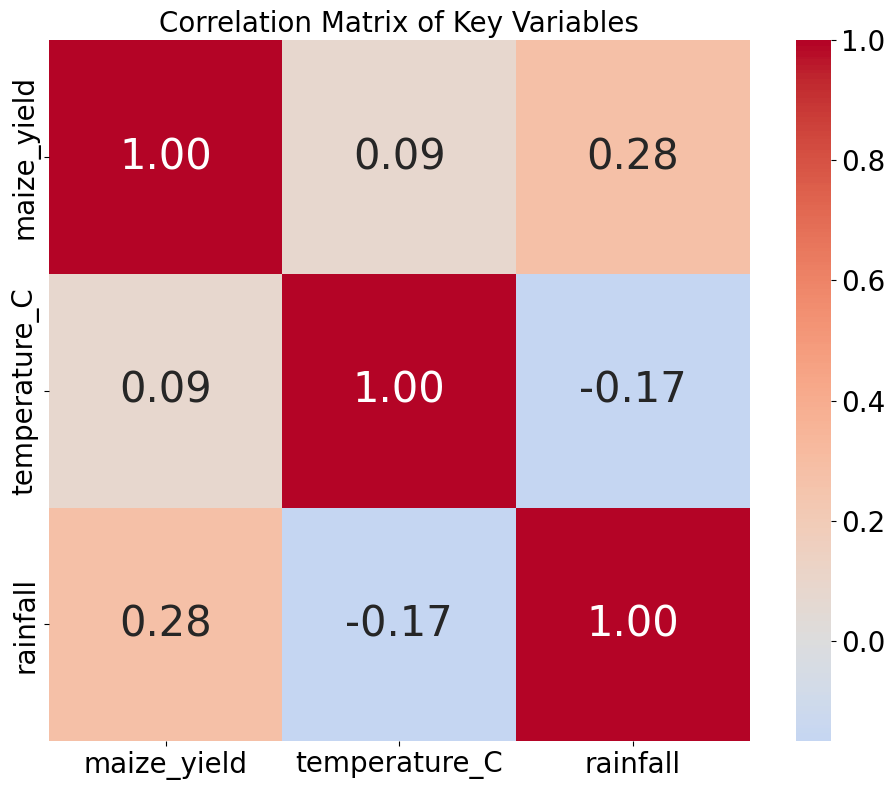


Saved: correlation_heatmap.png


In [4]:
#  CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
corr_vars = ['maize_yield', 'temperature_C', 'rainfall']
available_vars = [v for v in corr_vars if v in data.columns]
corr_matrix = data[available_vars].corr()

ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True,
                 annot_kws={'size': 30})  
plt.title('Correlation Matrix of Key Variables', fontsize=20)  

ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("\nSaved: correlation_heatmap.png")

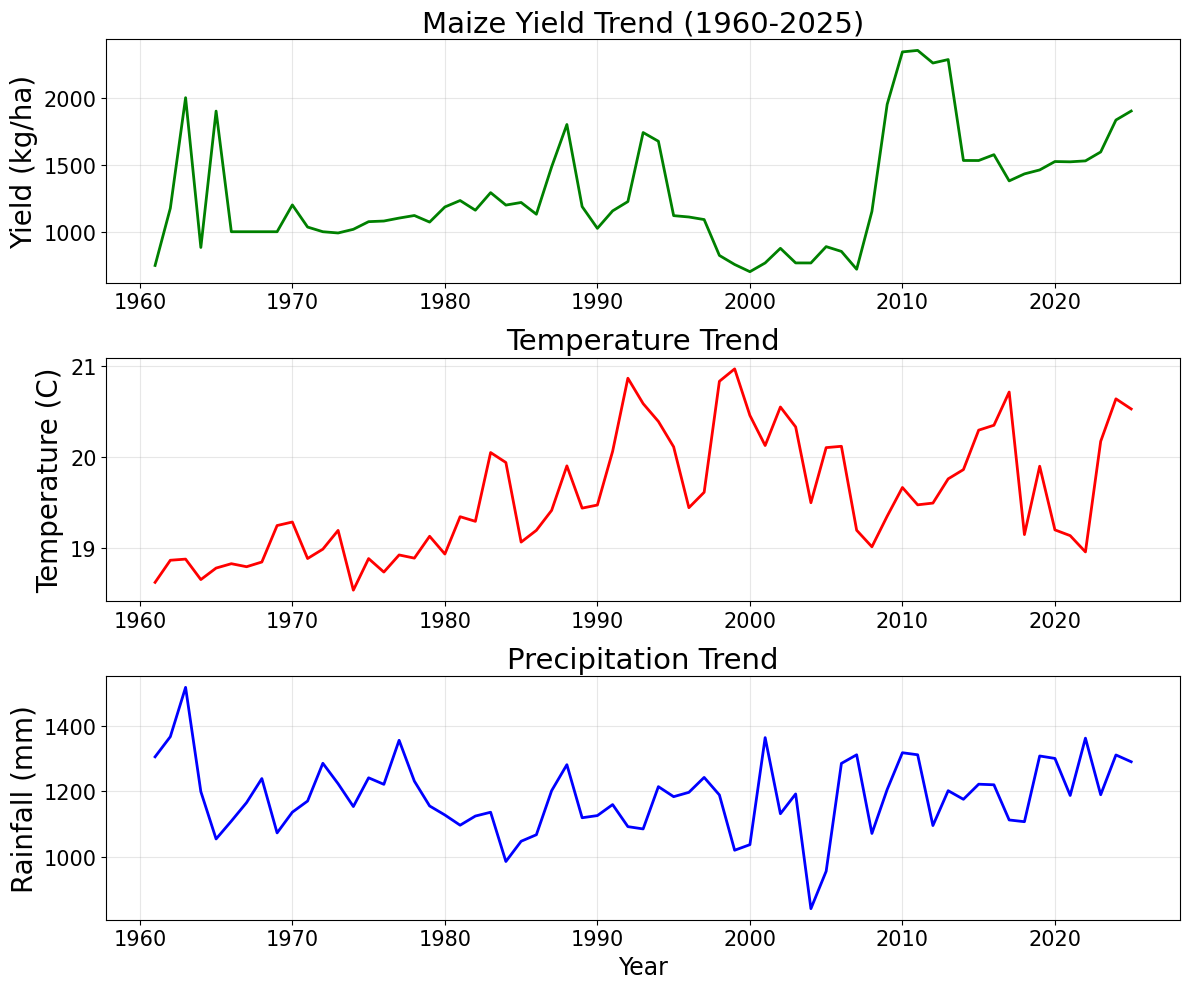

In [5]:
# TIME SERIES TRENDS PLOT 
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(data['year'], data['maize_yield'], 'g-', linewidth=2)
axes[0].set_title('Maize Yield Trend (1960-2025)', fontsize=21)  
axes[0].set_ylabel('Yield (kg/ha)', fontsize=20)  
axes[0].tick_params(axis='both', labelsize=15)  
axes[0].grid(True, alpha=0.3)

axes[1].plot(data['year'], data['temperature_C'], 'r-', linewidth=2)
axes[1].set_title('Temperature Trend', fontsize=21)  
axes[1].set_ylabel('Temperature (C)', fontsize=20)  
axes[1].tick_params(axis='both', labelsize=15)  
axes[1].grid(True, alpha=0.3)

axes[2].plot(data['year'], data['rainfall'], 'b-', linewidth=2)
axes[2].set_title('Precipitation Trend', fontsize=21)  
axes[2].set_xlabel('Year', fontsize=17)  
axes[2].set_ylabel('Rainfall (mm)', fontsize=20)  
axes[2].tick_params(axis='both', labelsize=15)  
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_trends.png', dpi=300)  
plt.savefig('time_series_trends.pdf', dpi=300)  
plt.show()

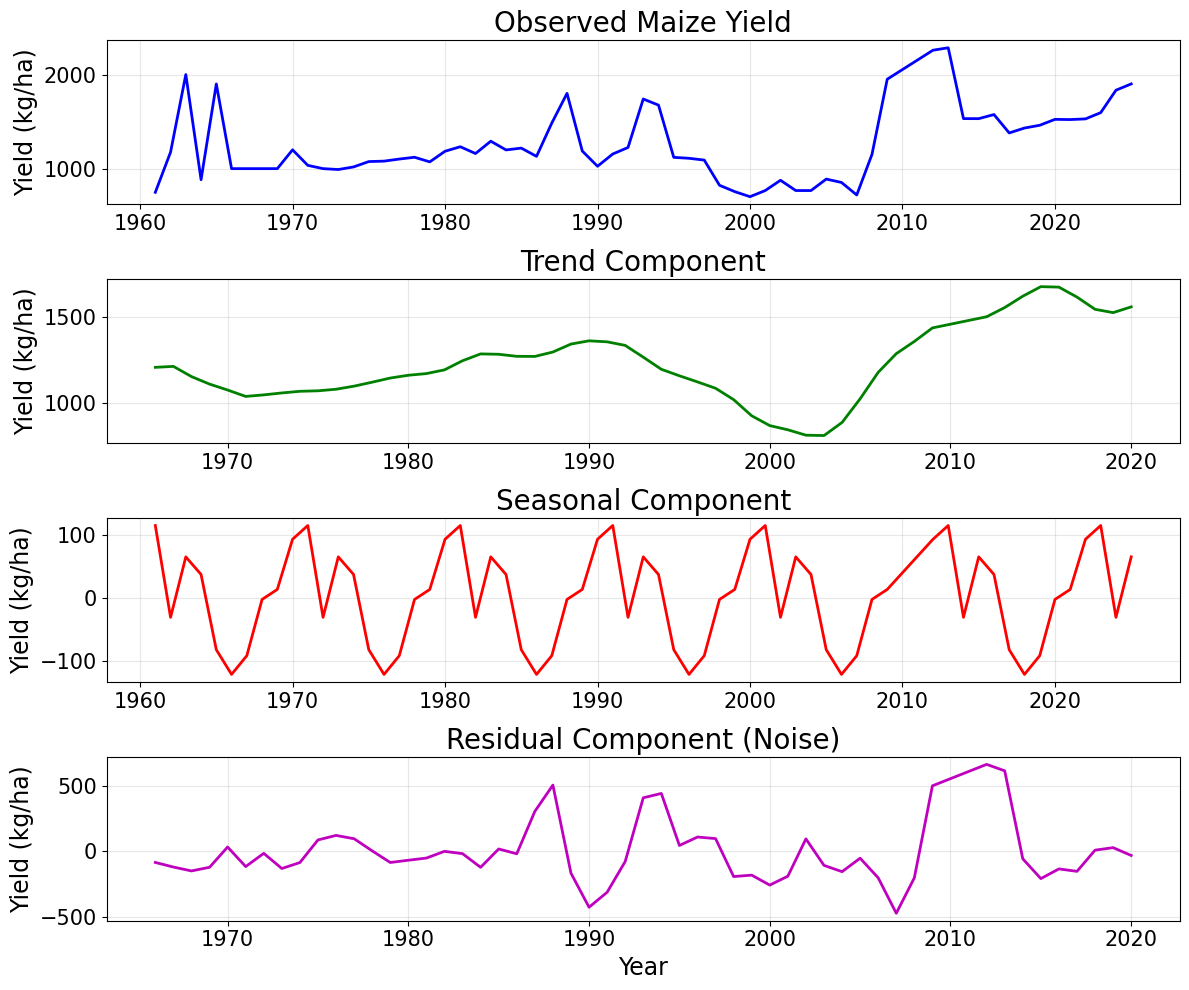

In [47]:
# TIME SERIES DECOMPOSITION 

data_copy = data.copy()
data_copy.set_index('year', inplace=True)

decomposition = seasonal_decompose(data_copy['maize_yield'].dropna(), model='additive', period=10)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(decomposition.observed, 'b-', linewidth=2)
axes[0].set_title('Observed Maize Yield', fontsize=20)
axes[0].set_ylabel('Yield (kg/ha)', fontsize=17)
axes[0].tick_params(axis='both', labelsize=15)
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomposition.trend, 'g-', linewidth=2)
axes[1].set_title('Trend Component', fontsize=20)
axes[1].set_ylabel('Yield (kg/ha)', fontsize=17)
axes[1].tick_params(axis='both', labelsize=15)
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(decomposition.seasonal, 'r-', linewidth=2)
axes[2].set_title('Seasonal Component', fontsize=20)
axes[2].set_ylabel('Yield (kg/ha)', fontsize=17)
axes[2].tick_params(axis='both', labelsize=15)
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(decomposition.resid, 'm-', linewidth=2)
axes[3].set_title('Residual Component (Noise)', fontsize=20)
axes[3].set_xlabel('Year', fontsize=17)
axes[3].set_ylabel('Yield (kg/ha)', fontsize=17)
axes[3].tick_params(axis='both', labelsize=15)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_decomposition.png', dpi=300)
plt.savefig('time_series_decomposition.pdf', dpi=300)
plt.show()

In [6]:
#  SUMMARY STATISTICS TABLE
stats_df = pd.DataFrame({
    'Variable': ['Yield_kg_ha', 'Temperature_C', 'Rainfall'],
    'Mean': [data['maize_yield'].mean(), data['temperature_C'].mean(), data['rainfall'].mean()],
    'Std Dev': [data['maize_yield'].std(), data['temperature_C'].std(), data['rainfall'].std()],
    'Min': [data['maize_yield'].min(), data['temperature_C'].min(), data['rainfall'].min()],
    '25%': [data['maize_yield'].quantile(0.25), data['temperature_C'].quantile(0.25), data['rainfall'].quantile(0.25)],
    '50%': [data['maize_yield'].median(), data['temperature_C'].median(), data['rainfall'].median()],
    '75%': [data['maize_yield'].quantile(0.75), data['temperature_C'].quantile(0.75), data['rainfall'].quantile(0.75)],
    'Max': [data['maize_yield'].max(), data['temperature_C'].max(), data['rainfall'].max()]
})

print(stats_df.to_string(index=False))
stats_df.to_csv('summary_statistics.csv', index=False)

     Variable        Mean    Std Dev        Min         25%         50%         75%         Max
  Yield_kg_ha 1284.644615 422.888800 701.800000 1000.000000 1160.600000 1528.600000 2352.900000
Temperature_C   19.566988   0.661194  18.538491   18.988003   19.437692   20.109231   20.963846
     Rainfall 1185.062722 112.348543 843.666700 1113.200000 1189.216700 1242.500000 1516.108300


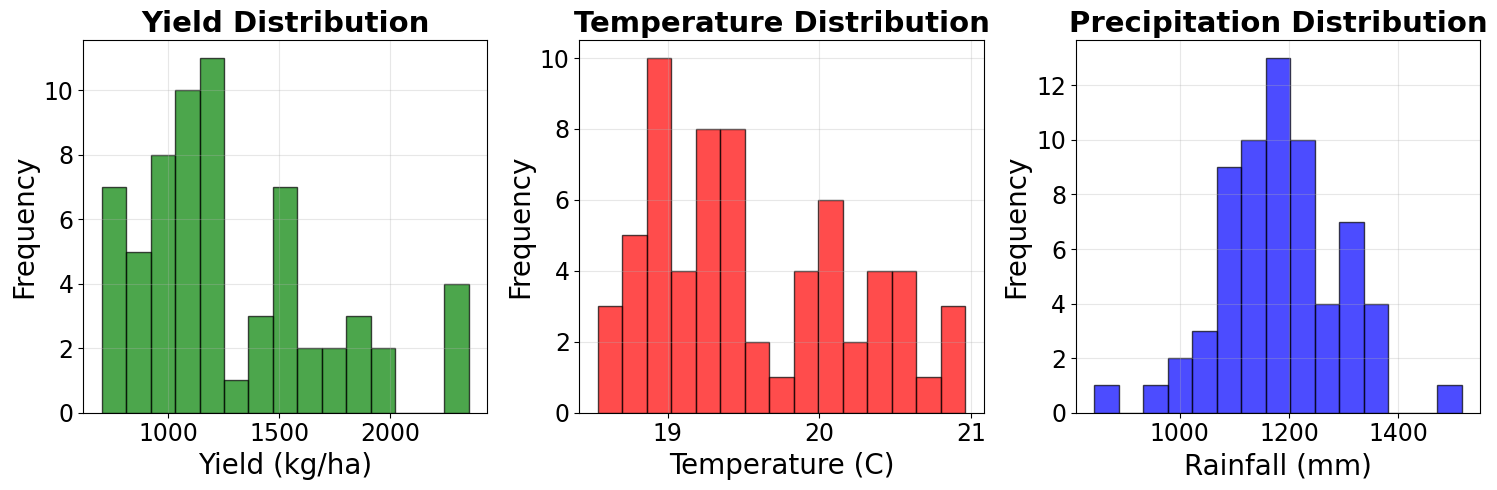

In [8]:
# DISTRIBUTION HISTOGRAMS 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(data['maize_yield'], bins=15, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Yield Distribution', fontsize=21, fontweight='bold')
axes[0].set_xlabel('Yield (kg/ha)', fontsize=20)
axes[0].set_ylabel('Frequency', fontsize=20)
axes[0].tick_params(axis='both', labelsize=17)
axes[0].grid(True, alpha=0.3)

axes[1].hist(data['temperature_C'], bins=15, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Temperature Distribution', fontsize=21, fontweight='bold')
axes[1].set_xlabel('Temperature (C)', fontsize=20)
axes[1].set_ylabel('Frequency', fontsize=20)
axes[1].tick_params(axis='both', labelsize=17)
axes[1].grid(True, alpha=0.3)

axes[2].hist(data['rainfall'], bins=15, color='blue', alpha=0.7, edgecolor='black')
axes[2].set_title('Precipitation Distribution', fontsize=21, fontweight='bold')
axes[2].set_xlabel('Rainfall (mm)', fontsize=20)
axes[2].set_ylabel('Frequency', fontsize=20)
axes[2].tick_params(axis='both', labelsize=17)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('variable_distributions.png', dpi=300)
plt.savefig('variable_distributions.pdf', dpi=300)
plt.show()

In [12]:
#  OUTLIER REMOVAL USING IQR METHOD
Q1 = data['maize_yield'].quantile(0.25)
Q3 = data['maize_yield'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['maize_yield'] >= lower_bound) & (data['maize_yield'] <= upper_bound)]

In [13]:

# AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST


def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test for {title}')
    print('-' * 50)
    
    # Perform ADF test
    result = adfuller(series, autolag='AIC')
    
    # Extract and display results
    adf_statistic = result[0]
    p_value = result[1]
    critical_values = result[4]
    
    print(f'ADF Statistic: {adf_statistic:.4f}')
    print(f'p-value: {p_value:.4f}')
    print(f'Critical Values:')
    for key, value in critical_values.items():
        print(f'    {key}: {value:.4f}')
    
    # Interpretation
    if p_value < 0.05:
        print(f'\n✓ Result: Series is STATIONARY (reject H0)')
    else:
        print(f'\n✗ Result: Series is NON-STATIONARY (fail to reject H0)')
    
    print('=' * 50)
    return result

# Test original series
adf_test(data['maize_yield'], 'Original Maize Yield Series')

# Test first differenced series
data['yield_diff_1'] = data['maize_yield'].diff()
adf_test(data['yield_diff_1'].dropna(), 'First-Differenced Maize Yield')

# Test second differenced series
data['yield_diff_2'] = data['maize_yield'].diff().diff()
adf_test(data['yield_diff_2'].dropna(), 'Second-Differenced Maize Yield')

Augmented Dickey-Fuller Test for Original Maize Yield Series
--------------------------------------------------
ADF Statistic: -2.7085
p-value: 0.0726
Critical Values:
    1%: -3.5424
    5%: -2.9102
    10%: -2.5927

✗ Result: Series is NON-STATIONARY (fail to reject H0)
Augmented Dickey-Fuller Test for First-Differenced Maize Yield
--------------------------------------------------
ADF Statistic: -7.1276
p-value: 0.0000
Critical Values:
    1%: -3.5444
    5%: -2.9111
    10%: -2.5932

✓ Result: Series is STATIONARY (reject H0)
Augmented Dickey-Fuller Test for Second-Differenced Maize Yield
--------------------------------------------------
ADF Statistic: -8.6056
p-value: 0.0000
Critical Values:
    1%: -3.5507
    5%: -2.9138
    10%: -2.5946

✓ Result: Series is STATIONARY (reject H0)


(-8.605550899601948,
 6.687759829688954e-14,
 3,
 57,
 {'1%': -3.5506699942762414,
  '5%': -2.913766394626147,
  '10%': -2.5946240473991997},
 688.9596121790828)

In [14]:
# TRAIN-TEST SPLIT AND SCALING
split = int(len(data) * 0.85)
train = data.iloc[:split]
test = data.iloc[split:]

y_train = train["maize_yield"]
y_test = test["maize_yield"]

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(train[["temperature_C", "rainfall"]])
X_test_scaled = scaler.transform(test[["temperature_C", "rainfall"]])

X_train = sm.add_constant(X_train_scaled)
X_test = sm.add_constant(X_test_scaled)

In [19]:
# TEST DIFFERENT ARIMA ORDERS (BASELINE - NO EXOGENOUS VARIABLES)

arima_orders = [(1,2,1), (2,2,1)]

baseline_results = []


y_test_clean = y_test.dropna()  
n_forecast = len(y_test_clean)  

for order in arima_orders:
    try:
       
        fit = ARIMA(y_train, order=order).fit()
        pred = fit.forecast(steps=n_forecast)  
        
        
        if len(pred) != len(y_test_clean):
            print(f"ARIMA{order} | Length mismatch: pred={len(pred)}, y_test={len(y_test_clean)}")
            continue
            
        r2 = r2_score(y_test_clean, pred)
        rmse = np.sqrt(mean_squared_error(y_test_clean, pred))
        mae = mean_absolute_error(y_test_clean, pred)
        mape = mean_absolute_percentage_error(y_test_clean, pred) * 100
        
        baseline_results.append({
            'order': order, 
            'R²': r2, 
            'RMSE': rmse,
            'MAE': mae, 
            'MAPE': mape,
            'AIC': fit.aic,
            'type': 'ARIMA (no climate)'
        })
        print(f"ARIMA{order} (no climate) | R²: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | AIC: {fit.aic:.1f}")
        
    except Exception as e:
        print(f"ARIMA{order} : {e}")

ARIMA(1, 2, 1) (no climate) | R²: 0.2796 | RMSE: 134.93 | MAE: 122.62 | MAPE: 7.78% | AIC: 753.1
ARIMA(2, 2, 1) (no climate) | R²: 0.2733 | RMSE: 135.51 | MAE: 123.31 | MAPE: 7.83% | AIC: 755.1


In [20]:

arima_model = ARIMA(y_train, order=(1,2,1)).fit()
arima_pred = arima_model.forecast(steps=len(test))

In [21]:
# TEST DIFFERENT ARIMA ORDERS 
print("="*60)
print("TESTING DIFFERENT ARIMA ORDERS")
print("="*60)


arima_orders = [(0,1,1), (1,1,0), (1,2,1), (2,1,0), (0,1,2), (2,2,1)]

results = []

for order in arima_orders:
    try:
        fit = ARIMA(y_train, exog=X_train, order=order).fit()
        pred = fit.forecast(steps=len(test), exog=X_test)
        r2 = r2_score(y_test, pred)
        
        results.append({'order': order, 'R²': r2, 'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
                       'MAE': mean_absolute_error(y_test, pred), 'AIC': fit.aic})
        print(f"ARIMAX{order} | R²: {r2:.4f} | AIC: {fit.aic:.1f}")
        
    except Exception as e:
        print(f"ARIMAX{order}")

if results:
    best = max(results, key=lambda x: x['R²'])
    print(f"\nBEST: ARIMAX{best['order']} | R²: {best['R²']:.4f} | AIC: {best['AIC']:.1f}")

TESTING DIFFERENT ARIMA ORDERS
ARIMAX(0, 1, 1) | R²: 0.3761 | AIC: 763.7
ARIMAX(1, 1, 0) | R²: 0.1515 | AIC: 763.7
ARIMAX(1, 2, 1) | R²: 0.6025 | AIC: 756.5
ARIMAX(2, 1, 0) | R²: 0.0328 | AIC: 765.7
ARIMAX(0, 1, 2) | R²: 0.1434 | AIC: 765.4
ARIMAX(2, 2, 1) | R²: 0.5406 | AIC: 758.5

BEST: ARIMAX(1, 2, 1) | R²: 0.6025 | AIC: 756.5


In [22]:
#  ARIMAX(1,2,1) BASELINE MODEL
model = ARIMA(y_train, exog=X_train, order=(1, 2, 1))
fit = model.fit()
arimax_pred = fit.forecast(steps=len(test), exog=X_test)

In [23]:

# SVR KERNEL + CONFIGURATION SELECTION ON ARIMAX RESIDUALS


print("="*70)
print("SVR KERNEL + CONFIGURATION COMPARISON")
print("="*70)

residuals = y_train - fit.fittedvalues
residuals_smoothed = residuals.rolling(3, min_periods=1).mean().bfill()

kernel_configs = [
    # RBF kernel configs
    {'kernel': 'rbf', 'C': 200, 'epsilon': 0.1, 'gamma': 'scale', 'name': 'RBF_C200'},
    {'kernel': 'rbf', 'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'name': 'RBF_C100'},

    # Linear kernel configs
    {'kernel': 'linear', 'C': 200, 'epsilon': 0.1, 'gamma': 'scale', 'name': 'LINEAR_C200'},
    {'kernel': 'linear', 'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'name': 'LINEAR_C100'},

    # Polynomial kernel configs
    {'kernel': 'poly', 'C': 200, 'epsilon': 0.1, 'gamma': 'scale', 'name': 'POLY_C200'},
    {'kernel': 'poly', 'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'name': 'POLY_C100'},
]

for config in kernel_configs:

    svr = SVR(
        kernel=config['kernel'],
        C=config['C'],
        epsilon=config['epsilon'],
        gamma=config['gamma']
    )

    svr.fit(X_train_scaled, residuals_smoothed)

    # Hybrid prediction
    svr_pred = svr.predict(X_test_scaled)
    hybrid_pred = arimax_pred + svr_pred

    # Metrics
    r2 = r2_score(y_test, hybrid_pred)
    rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
    mae = mean_absolute_error(y_test, hybrid_pred)

    print(
        f"{config['name']:18s} | "
        f"{config['kernel']:6s} | "
        f"C={config['C']:4.0f} | "
        f"ε={config['epsilon']:5.3f} | "
        f"R²={r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f}"
    )

SVR KERNEL + CONFIGURATION COMPARISON
RBF_C200           | rbf    | C= 200 | ε=0.100 | R²=0.7593 | RMSE=77.99 | MAE=68.34
RBF_C100           | rbf    | C= 100 | ε=0.010 | R²=0.7283 | RMSE=82.86 | MAE=69.89
LINEAR_C200        | linear | C= 200 | ε=0.100 | R²=0.5676 | RMSE=104.53 | MAE=84.01
LINEAR_C100        | linear | C= 100 | ε=0.010 | R²=0.5665 | RMSE=104.67 | MAE=84.15
POLY_C200          | poly   | C= 200 | ε=0.100 | R²=0.7402 | RMSE=81.03 | MAE=62.83
POLY_C100          | poly   | C= 100 | ε=0.010 | R²=0.7399 | RMSE=81.07 | MAE=62.87


In [24]:
#  SVR CONFIGURATIONS ON RESIDUES
print("="*60)
print("TESTING  SVR CONFIGURATIONS")
print("="*60)
residuals = y_train - fit.fittedvalues
residuals_smoothed = residuals.rolling(3, min_periods=1).mean().bfill()

top_configs = [
    {'C': 200, 'epsilon': 0.1, 'gamma': 'scale', 'name': 'C200_eps0.1'},
    {'C': 150, 'epsilon': 0.02, 'gamma': 'scale', 'name': 'C150_eps0.02'},
    {'C': 100, 'epsilon': 0.01, 'gamma': 1.0, 'name': 'C100_eps0.01_gamma1'},
    {'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'name': 'C100_eps0.01'},
    {'C': 50, 'epsilon': 0.05, 'gamma': 'scale', 'name': 'C50_eps0.05'},
]

for config in top_configs:
    svr = SVR(kernel='rbf', C=config['C'], epsilon=config['epsilon'], gamma=config['gamma'])
    svr.fit(X_train_scaled, residuals_smoothed)
    hybrid_pred = arimax_pred + svr.predict(X_test_scaled)
    
    r2 = r2_score(y_test, hybrid_pred)
    rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
    mae = mean_absolute_error(y_test, hybrid_pred)
    
    print(f"{config['name']:22s} | C={config['C']:4.0f} | ε={config['epsilon']:5.3f} | R²={r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f}")

TESTING  SVR CONFIGURATIONS
C200_eps0.1            | C= 200 | ε=0.100 | R²=0.7593 | RMSE=77.99 | MAE=68.34
C150_eps0.02           | C= 150 | ε=0.020 | R²=0.7421 | RMSE=80.73 | MAE=69.69
C100_eps0.01_gamma1    | C= 100 | ε=0.010 | R²=0.7329 | RMSE=82.15 | MAE=70.87
C100_eps0.01           | C= 100 | ε=0.010 | R²=0.7283 | RMSE=82.86 | MAE=69.89
C50_eps0.05            | C=  50 | ε=0.050 | R²=0.6719 | RMSE=91.06 | MAE=74.49


In [26]:
# SELECTED SVR MODEL ON RESIDUALS


# Train SVR on residuals
svr = SVR(kernel="rbf", C=200, epsilon=0.1, gamma="scale")
svr.fit(X_train_scaled, residuals_smoothed)

hybrid_pred = arimax_pred + svr.predict(X_test_scaled)

# Calculate errors
arima_errors = y_test.values - arima_pred.values
arimax_errors = y_test.values - arimax_pred.values
hybrid_errors = y_test.values - hybrid_pred

# Calculate MAPE
arima_mape = np.mean(np.abs(arima_errors / y_test.values)) * 100
arimax_mape = np.mean(np.abs(arimax_errors / y_test.values)) * 100
hybrid_mape = np.mean(np.abs(hybrid_errors / y_test.values)) * 100

# Calculate R², RMSE, MAE
arima_r2 = r2_score(y_test, arima_pred)
arimax_r2 = r2_score(y_test, arimax_pred)
hybrid_r2 = r2_score(y_test, hybrid_pred)

arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))
arimax_rmse = np.sqrt(mean_squared_error(y_test, arimax_pred))
hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))

arima_mae = mean_absolute_error(y_test, arima_pred)
arimax_mae = mean_absolute_error(y_test, arimax_pred)
hybrid_mae = mean_absolute_error(y_test, hybrid_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(f"ARIMA(1,2,1)       - R²: {arima_r2:.4f}, RMSE: {arima_rmse:.2f}, MAE: {arima_mae:.2f}, MAPE: {arima_mape:.2f}%")
print(f"ARIMAX(1,2,1)     - R²: {arimax_r2:.4f}, RMSE: {arimax_rmse:.2f}, MAE: {arimax_mae:.2f}, MAPE: {arimax_mape:.2f}%")
print(f"HYBRID            - R²: {hybrid_r2:.4f}, RMSE: {hybrid_rmse:.2f}, MAE: {hybrid_mae:.2f}, MAPE: {hybrid_mape:.2f}%")




MODEL PERFORMANCE COMPARISON
ARIMA(1,2,1)       - R²: 0.2796, RMSE: 134.93, MAE: 122.62, MAPE: 7.78%
ARIMAX(1,2,1)     - R²: 0.6025, RMSE: 100.23, MAE: 73.67, MAPE: 4.68%
HYBRID            - R²: 0.7593, RMSE: 77.99, MAE: 68.34, MAPE: 4.34%


In [27]:
# ACTUAL vs PREDICTED TABLE AND EXPORT (with ARIMA)


print("\n" + "="*60)
print("ACTUAL vs PREDICTED VALUES")
print("="*60)

comparison_df = pd.DataFrame({
    'Year': test['year'].values,
    'Actual': y_test.values,
    'ARIMA_Pred': arima_pred.values,
    'ARIMAX_Pred': arimax_pred.values,
    'Hybrid_Pred': hybrid_pred,
    'ARIMA_Error': np.abs(arima_errors),
    'ARIMAX_Error': np.abs(arimax_errors),
    'Hybrid_Error': np.abs(hybrid_errors),
    'ARIMA_Error_%': (np.abs(arima_errors) / y_test.values) * 100,
    'ARIMAX_Error_%': (np.abs(arimax_errors) / y_test.values) * 100,
    'Hybrid_Error_%': (np.abs(hybrid_errors) / y_test.values) * 100
})

print("\n", comparison_df.to_string(index=False))

comparison_df.to_csv('model_predictions_comparison.csv', index=False)
print("\nSaved: model_predictions_comparison.csv")


ACTUAL vs PREDICTED VALUES

  Year  Actual  ARIMA_Pred  ARIMAX_Pred  Hybrid_Pred  ARIMA_Error  ARIMAX_Error  Hybrid_Error  ARIMA_Error_%  ARIMAX_Error_%  Hybrid_Error_%
 2016  1574.8 1550.376214  1572.129973  1602.584461    24.423786      2.670027     27.784461       1.550914        0.169547        1.764317
 2017  1379.3 1563.813272  1579.449601  1494.931588   184.513272    200.149601    115.631588      13.377313       14.510955        8.383353
 2018  1431.5 1578.891521  1395.529187  1390.953826   147.391521     35.970813     40.546174      10.296299        2.512806        2.832426
 2019  1461.0 1593.492126  1582.929721  1560.842936   132.492126    121.929721     99.842936       9.068592        8.345635        6.833877
 2020  1523.7 1608.231743  1504.694988  1450.138971    84.531743     19.005012     73.561029       5.547794        1.247294        4.827790
 2021  1521.6 1622.930902  1462.415900  1446.187290   101.330902     59.184100     75.412710       6.659497        3.889597       

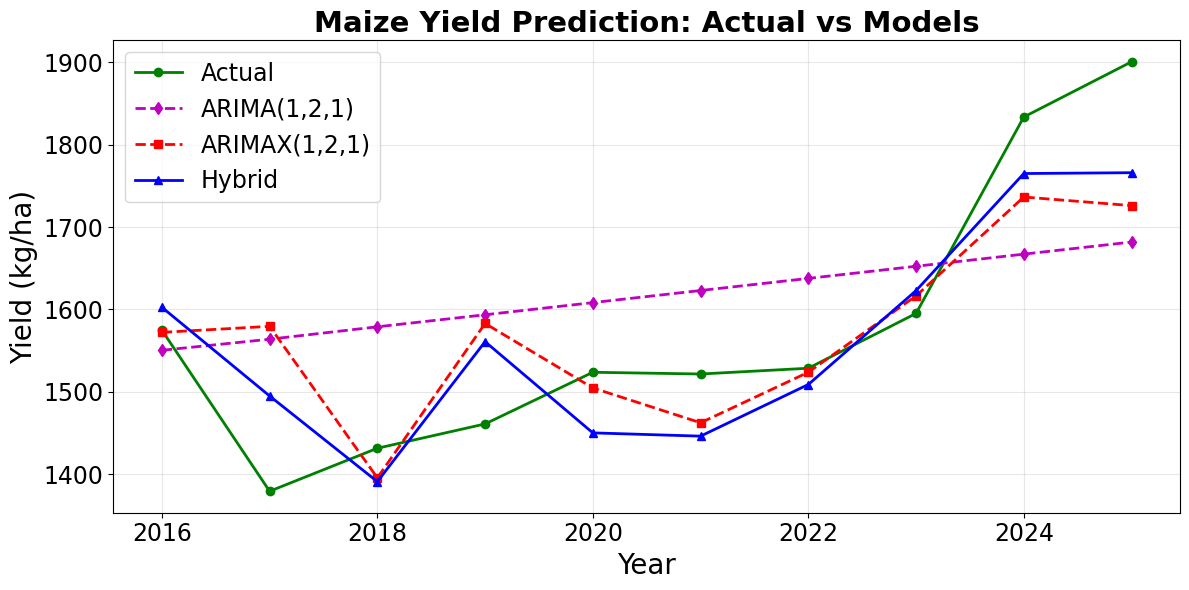

Saved: time_series_predictions.png and .pdf


In [20]:
# TIME SERIES PREDICTION PLOT
plt.figure(figsize=(12, 6))
years_test = test['year'].values

plt.plot(years_test, y_test.values, 'g-o', label='Actual', linewidth=2, markersize=6)
plt.plot(years_test, arima_pred, 'm--d', label='ARIMA(1,2,1)', linewidth=2)
plt.plot(years_test, arimax_pred.values, 'r--s', label='ARIMAX(1,2,1)', linewidth=2)
plt.plot(years_test, hybrid_pred, 'b-^', label='Hybrid', linewidth=2)

plt.title('Maize Yield Prediction: Actual vs Models', fontsize=21, fontweight='bold')
plt.xlabel('Year', fontsize=20)
plt.ylabel('Yield (kg/ha)', fontsize=20)
plt.legend(fontsize=17)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=17)  
plt.tight_layout()
plt.savefig('time_series_predictions.png', dpi=300)  
plt.savefig('time_series_predictions.pdf', dpi=300)  
plt.show()
print("Saved: time_series_predictions.png and .pdf")

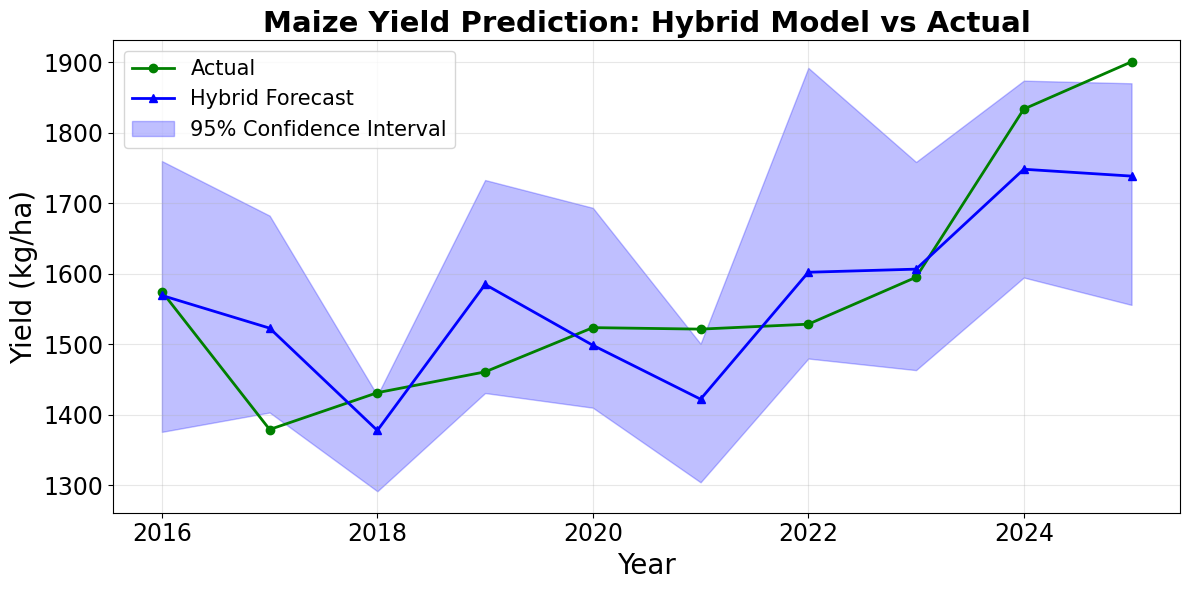

Saved: hybrid_vs_actual_with_ci.png and .pdf


In [29]:
# TIME SERIES PREDICTION PLOT: HYBRID vs ACTUAL with 95% CONFIDENCE INTERVAL
plt.figure(figsize=(12, 6))
years_test = test['year'].values

# Actual values
plt.plot(years_test, y_test.values, 'g-o', label='Actual', linewidth=2, markersize=6, color='green')

# HYBRID with 95% CI (using bootstrap)

n_bootstrap = 200
hybrid_preds_bootstrap = []

for i in range(n_bootstrap):
    indices = resample(range(len(X_train_scaled)), n_samples=len(X_train_scaled))
    svr_boot = SVR(kernel='rbf', C=200, epsilon=0.1, gamma='scale')
    svr_boot.fit(X_train_scaled[indices], residuals_smoothed.iloc[indices])
    hybrid_boot = arimax_pred + svr_boot.predict(X_test_scaled)
    hybrid_preds_bootstrap.append(hybrid_boot)

hybrid_lower = np.percentile(hybrid_preds_bootstrap, 2.5, axis=0)
hybrid_upper = np.percentile(hybrid_preds_bootstrap, 97.5, axis=0)
hybrid_pred_mean = np.mean(hybrid_preds_bootstrap, axis=0)

plt.plot(years_test, hybrid_pred_mean, 'b-^', label='Hybrid Forecast', linewidth=2, markersize=6, color='blue')
plt.fill_between(years_test, hybrid_lower, hybrid_upper, color='blue', alpha=0.25, label='95% Confidence Interval')

plt.title('Maize Yield Prediction: Hybrid Model vs Actual', fontsize=21, fontweight='bold')
plt.xlabel('Year', fontsize=20)
plt.ylabel('Yield (kg/ha)', fontsize=20)
plt.legend(fontsize=15)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=17)
plt.tight_layout()
plt.savefig('hybrid_vs_actual_with_ci.png', dpi=300)
plt.savefig('hybrid_vs_actual_with_ci.pdf', dpi=300)
plt.show()
print("Saved: hybrid_vs_actual_with_ci.png and .pdf")

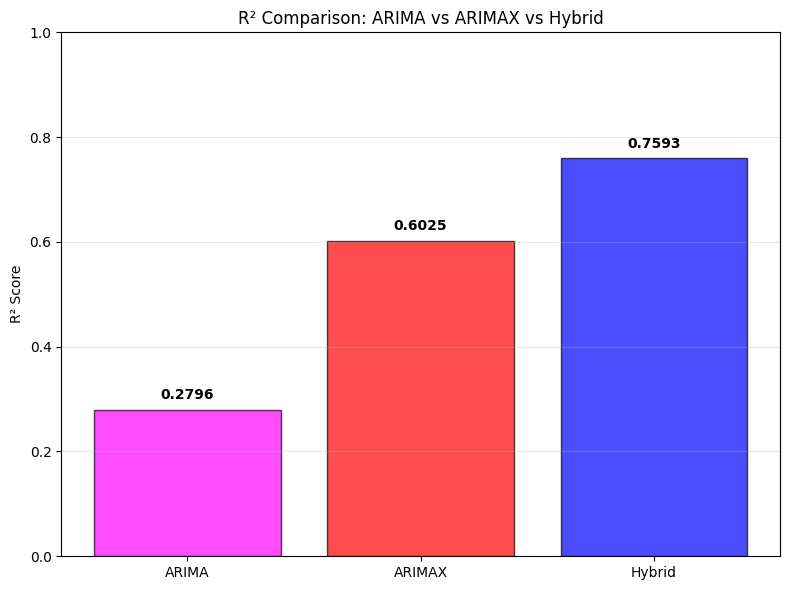

Saved: r2_comparison.png


In [30]:
# CELL: R² COMPARISON BAR CHART (with ARIMA baseline)
plt.figure(figsize=(8, 6))
models = ['ARIMA', 'ARIMAX', 'Hybrid']
r2_values = [arima_r2, arimax_r2, hybrid_r2]
colors = ['magenta', 'red', 'blue']

bars = plt.bar(models, r2_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('R² Score')
plt.title(f'R² Comparison: ARIMA vs ARIMAX vs Hybrid')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=150)
plt.show()
print("Saved: r2_comparison.png")

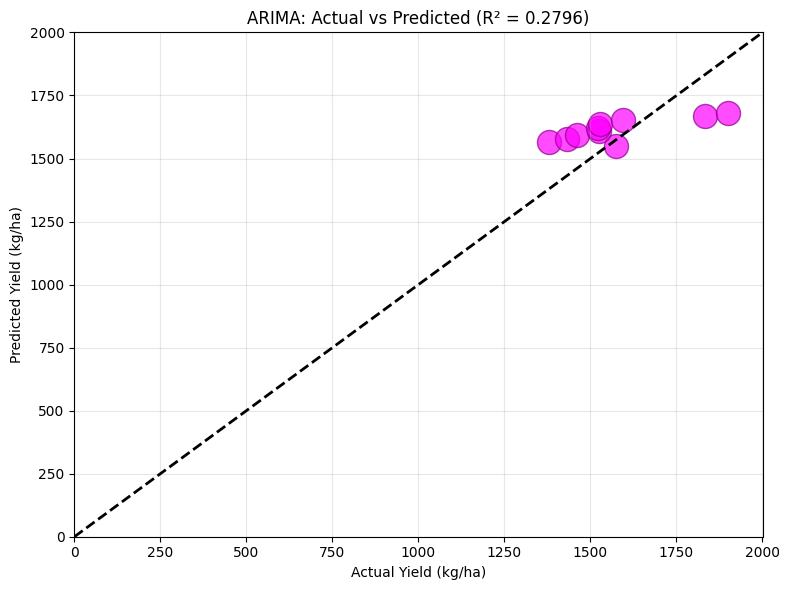

Saved: scatter_arima.png


In [39]:
#  SCATTER PLOT - ARIMA
plt.figure(figsize=(8, 6))
plt.scatter(y_test, arima_pred, alpha=0.7, s=300, color='magenta', edgecolors='darkmagenta')

min_val = 0
max_val = max(y_test.max(), arima_pred.max(), arimax_pred.max(), hybrid_pred.max()) + 100

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title(f'ARIMA: Actual vs Predicted (R² = {arima_r2:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_arima.png', dpi=150)
plt.show()
print("Saved: scatter_arima.png")

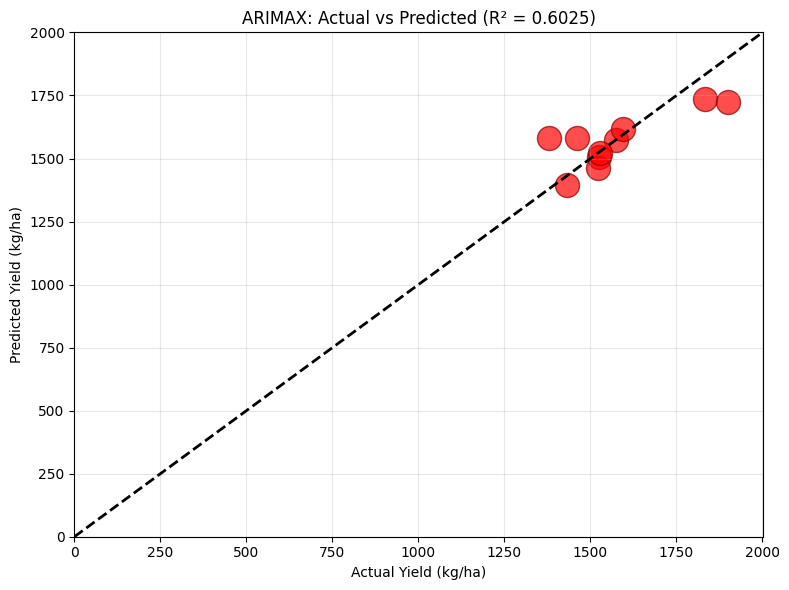

Saved: scatter_arimax.png


In [41]:
# SCATTER PLOT - ARIMAX
plt.figure(figsize=(8, 6))
plt.scatter(y_test, arimax_pred, alpha=0.7, s=300, color='red', edgecolors='darkred')

min_val = 0
max_val = max(y_test.max(), arimax_pred.max(), hybrid_pred.max()) + 100  # Add small padding

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title(f'ARIMAX: Actual vs Predicted (R² = {arimax_r2:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_arimax.png', dpi=150)
plt.show()
print("Saved: scatter_arimax.png")

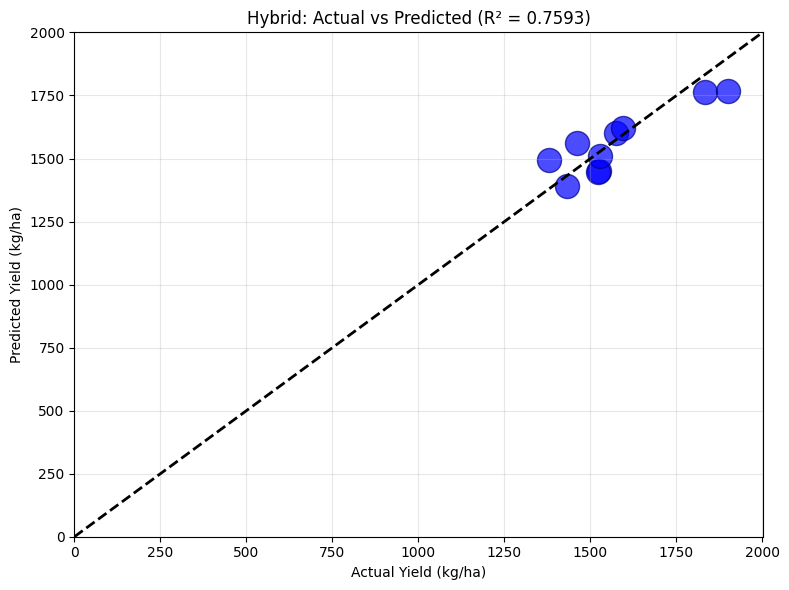

Saved: scatter_hybrid.png


In [42]:
# SCATTER PLOT - HYBRID
plt.figure(figsize=(8, 6))
plt.scatter(y_test, hybrid_pred, alpha=0.7, s=300, color='blue', edgecolors='darkblue')

min_val = 0
max_val = max(y_test.max(), hybrid_pred.max()) + 100  # Add small padding

plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title(f'Hybrid: Actual vs Predicted (R² = {hybrid_r2:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_hybrid.png', dpi=150)
plt.show()
print("Saved: scatter_hybrid.png")

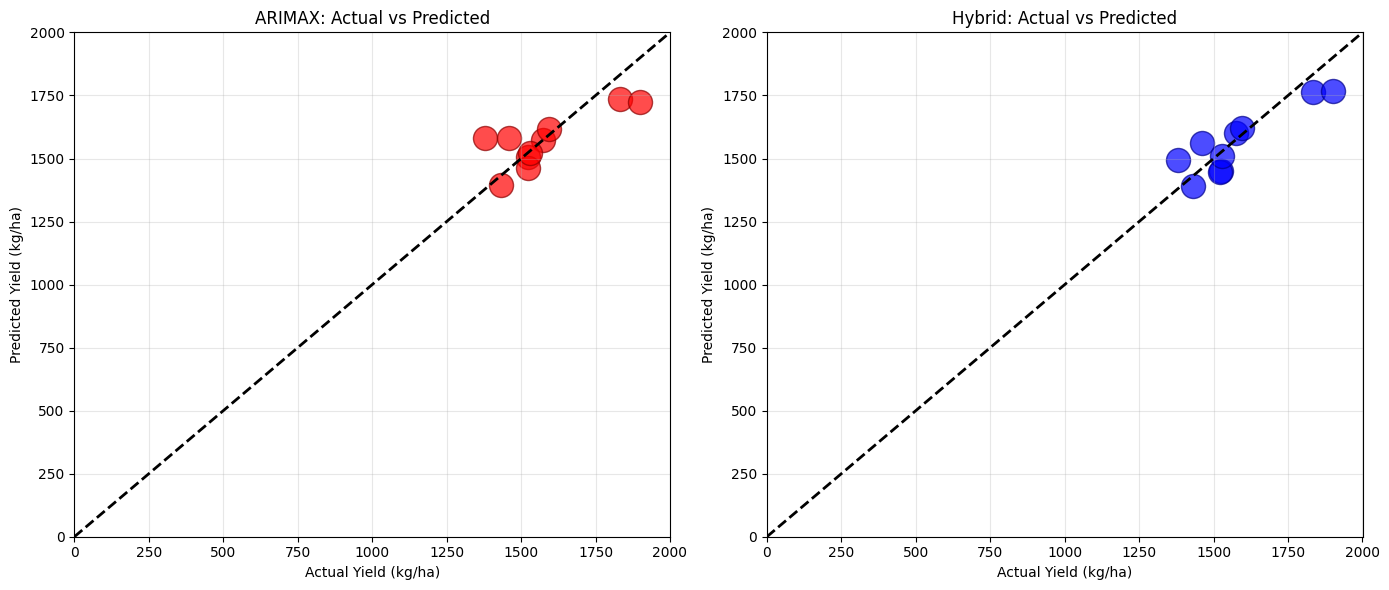

Saved: scatter_arimax_hybrid_comparison.png


In [43]:
# SCATTER PLOT - ARIMAX (LEFT) AND HYBRID (RIGHT)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


min_val = 0
max_val = max(y_test.max(), arimax_pred.max(), hybrid_pred.max()) + 100  # Add small padding

# Left plot - ARIMAX
ax1.scatter(y_test, arimax_pred, alpha=0.7, s=300, color='red', edgecolors='darkred')
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)
ax1.set_xlabel('Actual Yield (kg/ha)')
ax1.set_ylabel('Predicted Yield (kg/ha)')
ax1.set_title(f'ARIMAX: Actual vs Predicted')
ax1.grid(True, alpha=0.3)

# Right plot - HYBRID
ax2.scatter(y_test, hybrid_pred, alpha=0.7, s=300, color='blue', edgecolors='darkblue')
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
ax2.set_xlim(min_val, max_val)
ax2.set_ylim(min_val, max_val)
ax2.set_xlabel('Actual Yield (kg/ha)')
ax2.set_ylabel('Predicted Yield (kg/ha)')
ax2.set_title(f'Hybrid: Actual vs Predicted')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_arimax_hybrid_comparison.png', dpi=150)
plt.show()
print("Saved: scatter_arimax_hybrid_comparison.png")

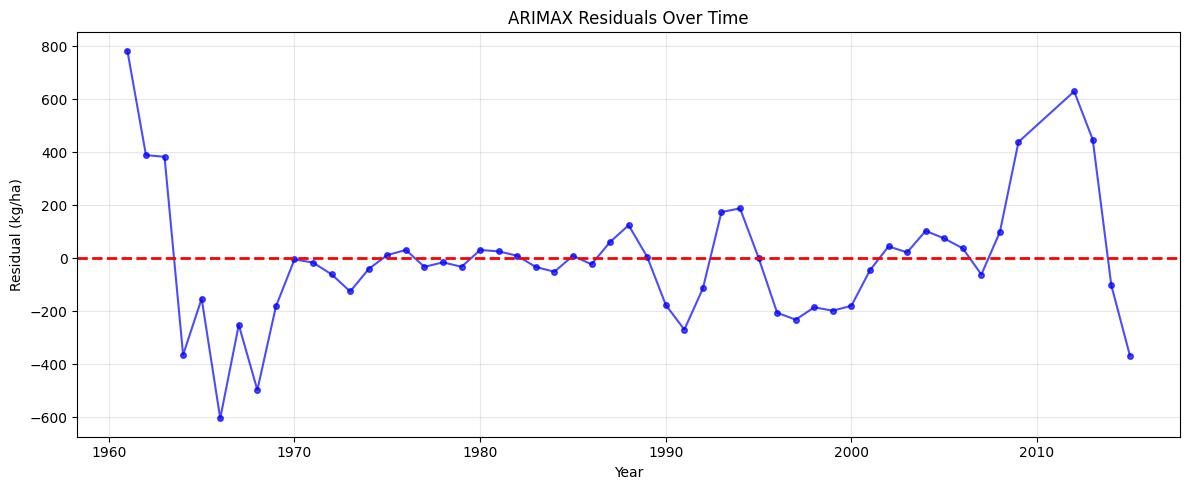


Saved: residual_analysis.png


In [45]:
#  RESIDUAL ANALYSIS PLOT (Residuals Over Time)
plt.figure(figsize=(12, 5))
plt.plot(train['year'].values, residuals_smoothed, 'b-o', markersize=4, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title('ARIMAX Residuals Over Time')
plt.xlabel('Year')
plt.ylabel('Residual (kg/ha)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150)
plt.show()
print("\nSaved: residual_analysis.png")